<a href="https://colab.research.google.com/github/sanskrutimishra2307-droid/Machine_Vision_Lab/blob/main/Machine_Vision_Prelab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install opencv-python
!pip install numpy
!pip install matplotlib

In [2]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

In [3]:
from google.colab import files

uploaded = files.upload()

Saving Image01.jpg to Image01.jpg


In [7]:
img = cv2.imread('Image01.jpg')

print("Image Loaded Successfully")

Image Loaded Successfully


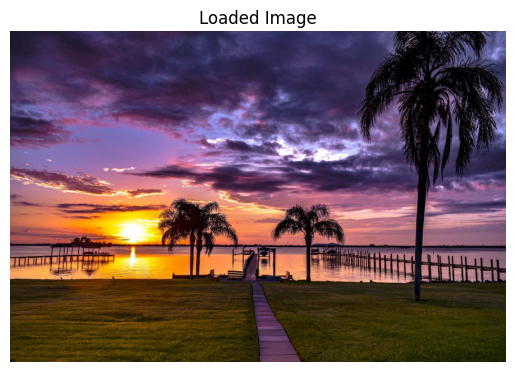

In [8]:
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

plt.imshow(img_rgb)
plt.title("Loaded Image")
plt.axis('off')
plt.show()

In [9]:
print("Dimensions:", img.shape)
print("Height:", img.shape[0])
print("Width:", img.shape[1])
print("Channels:", img.shape[2])
print("Data Type:", img.dtype)

Dimensions: (860, 1290, 3)
Height: 860
Width: 1290
Channels: 3
Data Type: uint8


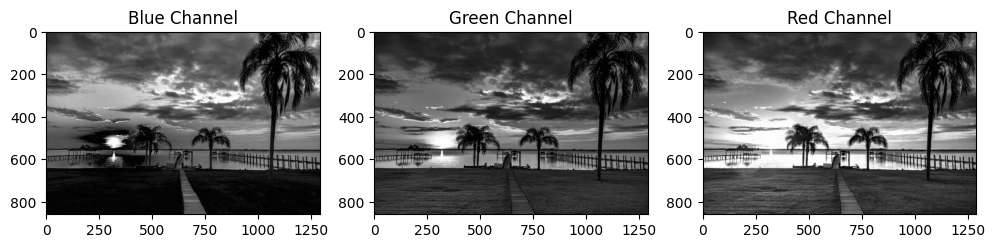

In [10]:
b, g, r = cv2.split(img)

plt.figure(figsize=(12,4))

plt.subplot(1,3,1)
plt.imshow(b, cmap='gray')
plt.title("Blue Channel")

plt.subplot(1,3,2)
plt.imshow(g, cmap='gray')
plt.title("Green Channel")

plt.subplot(1,3,3)
plt.imshow(r, cmap='gray')
plt.title("Red Channel")

plt.show()

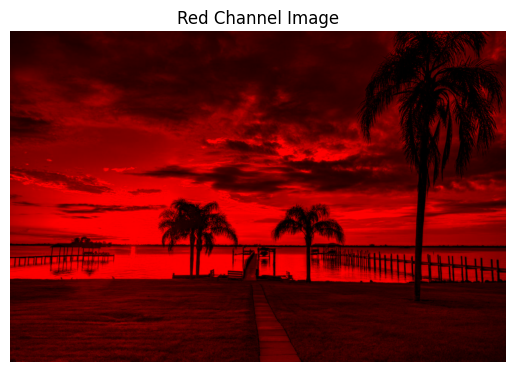

In [11]:
red_img = img.copy()
red_img[:,:,0] = 0
red_img[:,:,1] = 0

plt.imshow(cv2.cvtColor(red_img, cv2.COLOR_BGR2RGB))
plt.title("Red Channel Image")
plt.axis('off')
plt.show()

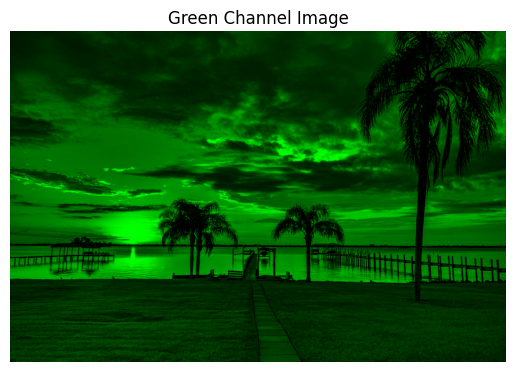

In [12]:
green_img = img.copy()
green_img[:,:,0] = 0
green_img[:,:,2] = 0

plt.imshow(cv2.cvtColor(green_img, cv2.COLOR_BGR2RGB))
plt.title("Green Channel Image")
plt.axis('off')
plt.show()

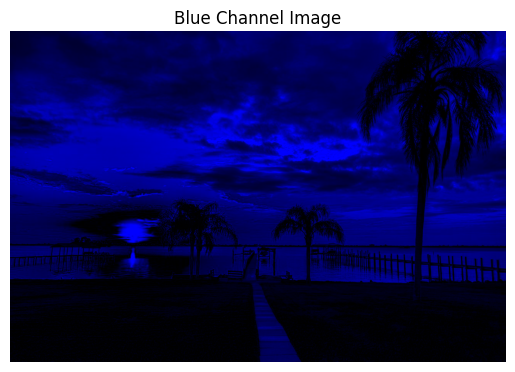

In [13]:
blue_img = img.copy()
blue_img[:,:,1] = 0
blue_img[:,:,2] = 0

plt.imshow(cv2.cvtColor(blue_img, cv2.COLOR_BGR2RGB))
plt.title("Blue Channel Image")
plt.axis('off')
plt.show()

In [16]:
uploaded = files.upload()

Saving sample.mp4 to sample.mp4


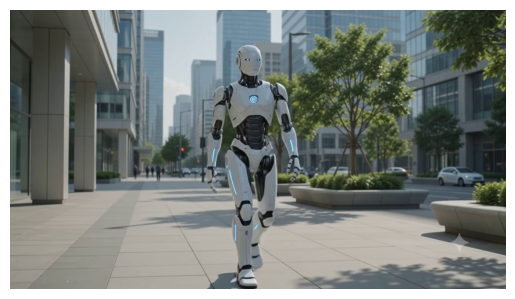

In [17]:
video = cv2.VideoCapture('sample.mp4')

while video.isOpened():
    ret, frame = video.read()

    if not ret:
        break

    frame_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)

    plt.imshow(frame_rgb)
    plt.axis('off')
    plt.show()

    break

video.release()

In [18]:
from IPython.display import Javascript
from google.colab.output import eval_js
from base64 import b64decode

In [19]:
def take_photo(filename='photo.jpg', quality=0.8):

    js = Javascript('''
    async function takePhoto(quality) {
      const div = document.createElement('div');
      const capture = document.createElement('button');
      capture.textContent = 'Capture';
      div.appendChild(capture);

      const video = document.createElement('video');
      video.style.display = 'block';

      const stream = await navigator.mediaDevices.getUserMedia({video: true});

      document.body.appendChild(div);
      div.appendChild(video);

      video.srcObject = stream;
      await video.play();

      google.colab.output.setIframeHeight(document.documentElement.scrollHeight,true);

      await new Promise((resolve) => capture.onclick = resolve);

      const canvas = document.createElement('canvas');
      canvas.width = video.videoWidth;
      canvas.height = video.videoHeight;

      canvas.getContext('2d').drawImage(video,0,0);

      stream.getTracks()[0].stop();
      div.remove();

      return canvas.toDataURL('image/jpeg', quality);
    }
    ''')

    display(js)

    data = eval_js('takePhoto({})'.format(quality))
    binary = b64decode(data.split(',')[1])

    with open(filename, 'wb') as f:
        f.write(binary)

    return filename